## What is the number of errors compared to the number of Put Outs? 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [2]:
hitter_data = pd.read_csv("Hitters.csv.xls")

In [3]:
hitter_data

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [4]:
hitter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [5]:
errors = hitter_data["Errors"]
putouts = hitter_data["PutOuts"]

In [20]:
corr = scipy.stats.pearsonr(errors, putouts)
print(corr)

correlation_score = corr[0]
print("The Correlation Score is:", correlation_score)
# Correlation Score of Amount of Errors compared to Amount of Put Outs

PearsonRResult(statistic=np.float64(0.10997154318620815), pvalue=np.float64(0.04864632651309045))
The Correlation Score is: 0.10997154318620815


In [7]:
linear_model = scipy.stats.linregress(errors, putouts)

print(linear_model)

LinregressResult(slope=np.float64(4.8473271025005324), intercept=np.float64(249.9635718373482), rvalue=np.float64(0.10997154318620814), pvalue=np.float64(0.048646326513090234), stderr=np.float64(2.44909080312474), intercept_stderr=np.float64(25.10498938035086))


In [8]:
slope = linear_model[0]
print(slope)

4.8473271025005324


In [9]:
y_intercept = linear_model.intercept

In [10]:
linear_fit = slope*errors+y_intercept

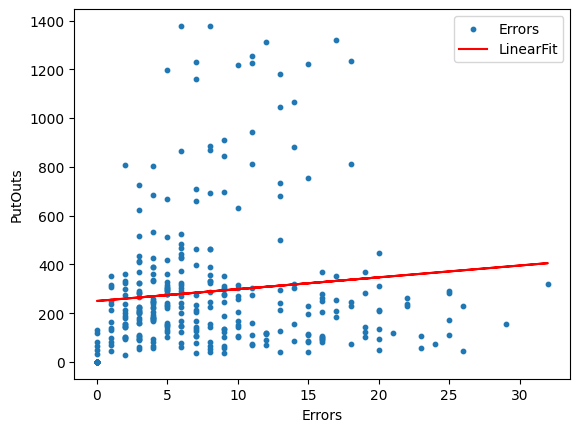

In [19]:
plt.scatter(errors, putouts, s=10,label="Errors")
plt.plot(errors, linear_fit, color="red", label=("LinearFit"))
plt.xlabel("Errors")
plt.ylabel("PutOuts")
plt.legend()

In [12]:
# another graph

In [13]:
Errors_ = hitter_data["Errors"].value_counts()
Errors_

Errors
3     33
4     28
5     26
6     23
0     21
2     21
8     20
9     18
7     18
1     13
10    12
16    11
11    10
13    10
15     9
20     7
14     6
12     6
17     5
19     5
18     5
25     4
22     3
26     2
23     2
24     1
21     1
29     1
32     1
Name: count, dtype: int64

In [14]:
Putouts_ = hitter_data["PutOuts"].value_counts()
Putouts_

PutOuts
0       15
325      5
102      4
211      4
303      4
        ..
942      1
1222     1
313      1
1314     1
408      1
Name: count, Length: 232, dtype: int64

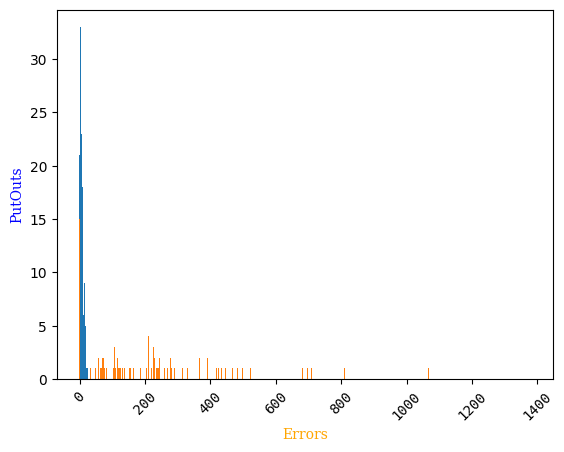

In [15]:
plt.bar(Errors_.index, Errors_)
plt.bar(Putouts_.index, Putouts_)
plt.xlabel("Errors", fontfamily="serif", c="orange")
plt.ylabel("PutOuts", fontfamily="serif", c="blue")
plt.xticks(fontsize=10, fontfamily="monospace", rotation=45)
plt.show()  

In [16]:
# As you can see from this, there is a significantly less amount of errors compared to the Putouts. 

In [17]:
import pandas as pd

# Load your dataset into a Pandas DataFrame
hitter_data = pd.read_csv('Hitters.csv.xls') 

# Calculate the average of each column
column_means = hitter_data.mean(numeric_only=True)

# Print the result
print(column_means)

AtBat       380.928571
Hits        101.024845
HmRun        10.770186
Runs         50.909938
RBI          48.027950
Walks        38.742236
Years         7.444099
CAtBat     2648.683230
CHits       717.571429
CHmRun       69.490683
CRuns       358.795031
CRBI        330.118012
CWalks      260.239130
PutOuts     288.937888
Assists     106.913043
Errors        8.040373
Salary      535.925882
dtype: float64


In [18]:
# As you can see from this, the average amount of errors is 8.04 compared to the average amount of putouts which is 288.93